In [ ]:
import sys; sys.path.append('../3rdparty/ElasticRods/python')

import elastic_rods
from linkage_vis import LinkageViewer as Viewer
import numpy as np, matplotlib.pyplot as plt, matplotlib, os, json

from elastic_knots import *
from elastic_rods import ElasticRod, PeriodicRod, RodMaterial, EnergyType

import fd_validation

%load_ext autoreload
%autoreload 2

In [26]:
p1 = np.random.uniform(size=3)
p2 = np.random.uniform(size=3)
p3 = np.random.uniform(size=3)
p4 = np.random.uniform(size=3)
p5 = np.random.uniform(size=3)
stiffness1 = np.random.uniform(size=1)[0]
#l = np.random.uniform(size=1)[0]
l = 1

# s = Spring([p1,p2,p3,p4,p5],stiffness1,l, CompressionType.Compression)
s = Spring([p1,p2,p3,p4,p5],stiffness1,l, CompressionType.NoCompression)

In [27]:
s.getCoords(), s.isCompressed()

([array([0.68685675, 0.99756779, 0.79636986]),
  array([0.65780228, 0.24585481, 0.63766117]),
  array([0.86487994, 0.55491194, 0.32793664]),
  array([0.12974425, 0.39073153, 0.10307446]),
  array([0.69316677, 0.01795687, 0.95213948])],
 False)

In [28]:
s.getRestLength(), 

(1.0,)

In [29]:
class SpringWrapper:
    def __init__(self,g_spring):
        self.spring = g_spring
        self.numvars = len(g_spring.getCoords()) * 3 #+ 1
        
    def setVars(self, v):
        self.spring.setCoords(v.reshape(-1,3))
    def numVars(self):
        return self.numvars
    def getVars(self):
        v = np.array(self.spring.getCoords()).reshape(-1)
        return v

    def energy(self):
        return self.spring.energy()
    def gradient(self):  
        g = self.spring.dE_dx()
        return g
    def hessian(self):
        h = self.spring.d2E_dx2()
        return h

In [30]:
sw = SpringWrapper(s)

In [31]:
direction = np.random.uniform(size=sw.numVars())

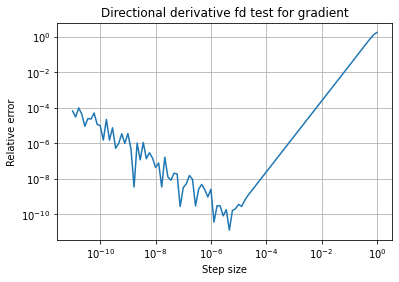

In [32]:
fd_validation.gradConvergencePlot(sw, perturb=direction,epsilons=np.logspace(-11, 0, 100))

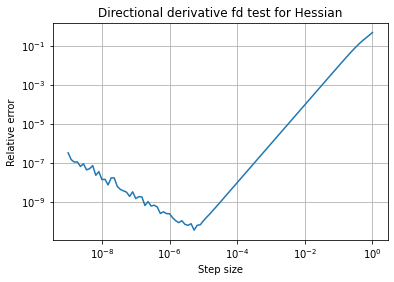

In [33]:
fd_validation.hessConvergencePlot(sw, perturb=direction, epsilons=np.logspace(-9, 0, 100))

In [34]:
# The rest state of the elastic ring
radius = 5.0
n_division = 11

thetas = np.linspace(0, 2 * np.pi, n_division, endpoint=True)
thetas = np.concatenate([thetas, [thetas[1]]])  # last and first edge overlap
xs = radius * np.cos(thetas)
ys = radius * np.sin(thetas)
zs = np.zeros_like(xs)

rod_points = np.column_stack([xs, ys, zs])

rod = PeriodicRod(rod_points, zeroRestCurvature=True)
rod_youngs_modulus = 1e6
material = RodMaterial('ellipse', rod_youngs_modulus, 0.5, [0.05, 0.05])  # circular cross-section
rod.setMaterial(material)

In [10]:
s2 = Spring([np.zeros(3), np.zeros(3)],stiffness1,l)

In [11]:
rod_idx = np.array([0,0])
rod_vertices = np.array([0,int((n_division - 1)/2)])
spring_vertices = np.array([0,1])
av1 = SpringAttachments(rod_idx,rod_vertices,spring_vertices)

In [12]:
tencer = ContactTencer([rod],[s2],[av1])

In [13]:
class TencerWrapper:
    def __init__(self,tencer:ContactTencer):
        self.tencer = tencer
        
    def setVars(self, v):
        self.tencer.setDefoVars(v)
    def numVars(self):
        return tencer.numDefoVars()
    def getVars(self):
        return self.tencer.getDefoVars()

    def energy(self):
        return self.tencer.energy()
    def gradient(self):  
        g = self.tencer.gradient()
        return g
    def hessian(self):
        return self.tencer.hessian()

In [14]:
direction = np.random.uniform(size=tencer.numDefoVars())

In [15]:
tw = TencerWrapper(tencer)

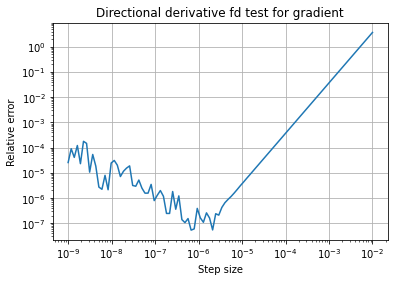

In [16]:
fd_validation.gradConvergencePlot(tw, perturb=direction,epsilons=np.logspace(-9, -2, 100))

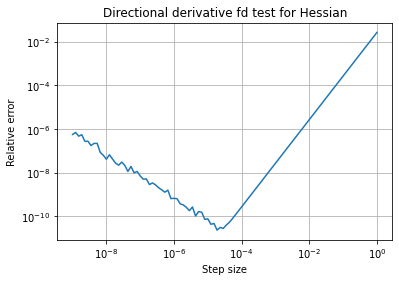

In [17]:
fd_validation.hessConvergencePlot(tw, perturb=direction, epsilons=np.logspace(-9, 0, 100))

In [18]:
s3 = Spring([np.zeros(3), p1, np.zeros(3)],stiffness1,l)
stiffness2 = 10
l2 = 5
s4 = Spring([np.zeros(3), p2, np.zeros(3), np.zeros(3)],stiffness2,l2)

In [19]:
rod_idx = np.array([0,0])
rod_vertices = np.array([0,int((n_division - 1)/2)])
spring_vertices = np.array([0,2])
av2 = SpringAttachments(rod_idx,rod_vertices,spring_vertices)
rod_idx = np.array([0,0,0])
rod_vertices = np.array([1,9,4])
spring_vertices = np.array([0,2,3])
av3 = SpringAttachments(rod_idx,rod_vertices,spring_vertices)

In [34]:
# tencer2 = ContactTencer([rod],[s2,s3],[av1,av2])
tencer2 = ContactTencer([rod],[s2,s3,s4],[av1,av2,av3])

In [46]:
tw = TencerWrapper(tencer2)

In [47]:
direction = np.random.uniform(size=tencer2.numDefoVars())

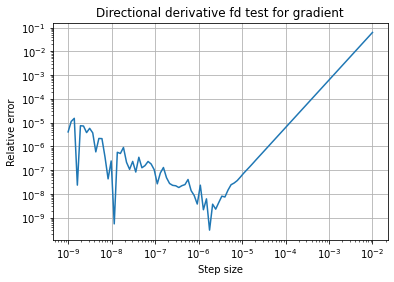

In [48]:
fd_validation.gradConvergencePlot(tw, perturb=direction,epsilons=np.logspace(-9, -2, 100))

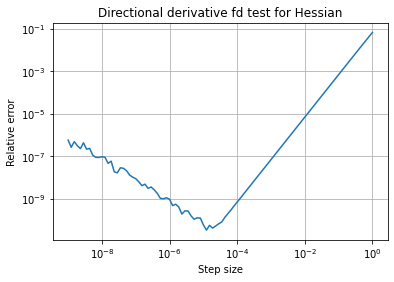

In [49]:
fd_validation.hessConvergencePlot(tw, perturb=direction, epsilons=np.logspace(-9, 0, 100))

In [52]:
tencer3 = ContactTencer(tencer2)

In [53]:
tw = TencerWrapper(tencer3)

In [54]:
direction = np.random.uniform(size=tencer3.numDefoVars())

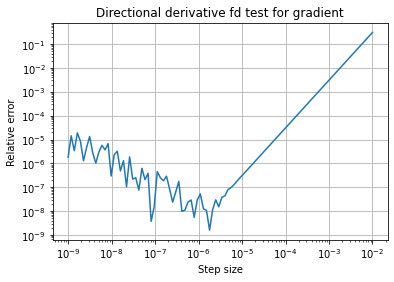

In [55]:
fd_validation.gradConvergencePlot(tw, perturb=direction,epsilons=np.logspace(-9, -2, 100))

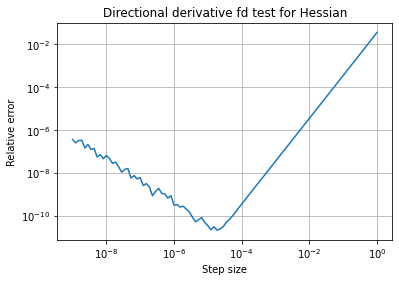

In [56]:
fd_validation.hessConvergencePlot(tw, perturb=direction, epsilons=np.logspace(-9, 0, 100))